# demo_combine_data.ipynb

This notebook demonstrates how to combine data from the water area curves (from Dunmire+) and the imagery sequences (generated by sat-tile-stack) into one unified .nc file per lake.


In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

from lakevision.data.preprocessing import combine_lake_data, load_area_sequences


saved combined dataset to ../datasets/processed/CW2019_1579.nc
<xarray.Dataset> Size: 642MB
Dimensions:     (time: 153, channel: 4, y: 512, x: 512)
Coordinates:
  * time        (time) datetime64[ns] 1kB 2019-05-01 2019-05-02 ... 2019-09-30
  * channel     (channel) <U5 80B 'red' 'green' 'blue' 'mask'
    lake_id     <U11 44B 'CW2019_1579'
Dimensions without coordinates: y, x
Data variables:
    imagery     (time, channel, y, x) float32 642MB nan nan nan ... 0.0 0.0 0.0
    water_area  (time) float64 1kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0007238 0.0 0.0
Attributes:
    description:     Combined lake drainage dataset
    lake_id:         CW2019_1579
    year:            2019
    source_imagery:  ../datasets/imgseqs/tstack_CW2019_1579.nc
Imagery shape: (153, 4, 512, 512)
Water area shape: (153,)


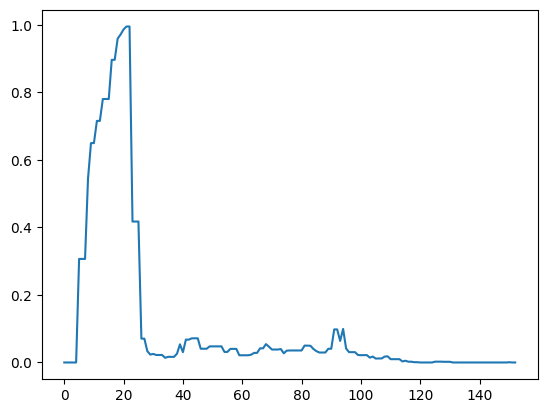

In [9]:
# Load area data
area_ds = load_area_sequences(
    '../datasets/areaseqs/all_lakes_2019.nc',
    lake_ids='CW2019_1579'
)

# Combine
ds = combine_lake_data(
    imagery_path='../datasets/imgseqs/tstack_CW2019_1579.nc',
    area_ds=area_ds,
    lake_id='CW2019_1579',
    output_path='../datasets/processed/CW2019_1579.nc'
)

# Inspect
print(ds)
print(f"Imagery shape: {ds['imagery'].shape}")
print(f"Water area shape: {ds['water_area'].shape}")

# Visualize
plt.plot(ds['water_area'])
plt.show()

In [10]:
ds

<xarray.Dataset> Size: 642MB
Dimensions:     (time: 153, channel: 4, y: 512, x: 512)
Coordinates:
  * time        (time) datetime64[ns] 1kB 2019-05-01 2019-05-02 ... 2019-09-30
  * channel     (channel) <U5 80B 'red' 'green' 'blue' 'mask'
    lake_id     <U11 44B 'CW2019_1579'
Dimensions without coordinates: y, x
Data variables:
    imagery     (time, channel, y, x) float32 642MB nan nan nan ... 0.0 0.0 0.0
    water_area  (time) float64 1kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0007238 0.0 0.0
Attributes:
    description:     Combined lake drainage dataset
    lake_id:         CW2019_1579
    year:            2019
    source_imagery:  ../datasets/imgseqs/tstack_CW2019_1579.nc

Max water area at timestep 21 (2019-05-22T00:00:00.000000000)


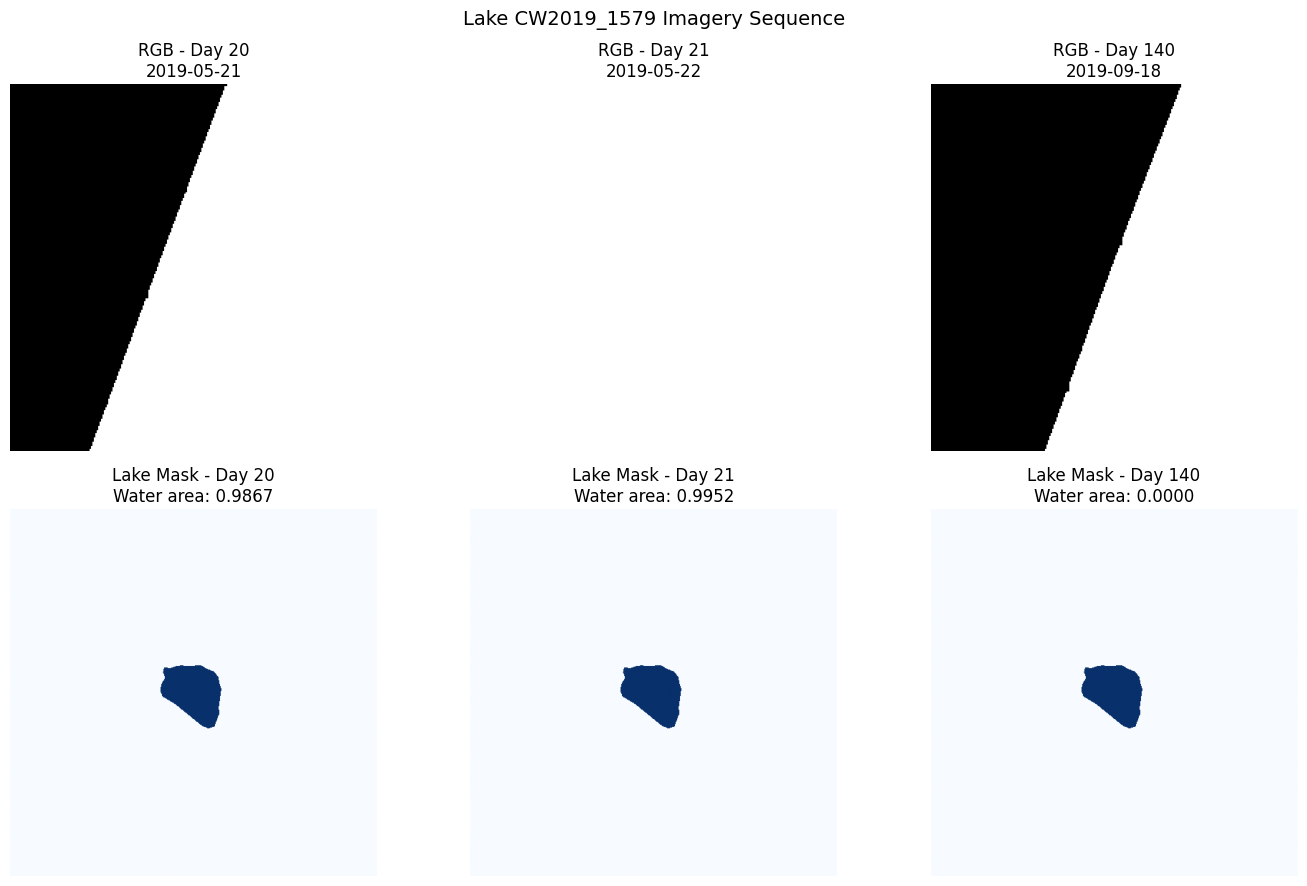

In [11]:
# Visualize imagery at different timesteps
# Find timestep with max water area for interesting imagery
max_area_idx = int(ds['water_area'].argmax().values)
print(f"Max water area at timestep {max_area_idx} ({ds['time'].values[max_area_idx]})")

# Select a few timesteps to visualize: early, peak, and late season
timesteps = [20, max_area_idx, 140]
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for i, t in enumerate(timesteps):
    # Get RGB channels and stack to (H, W, 3)
    rgb = ds['imagery'].isel(time=t, channel=[0, 1, 2]).values  # (3, H, W)
    rgb = np.transpose(rgb, (1, 2, 0))  # (H, W, 3)
    
    # Normalize for display (handle NaNs and scale to 0-1)
    rgb = np.nan_to_num(rgb, nan=0.0)
    rgb = np.clip(rgb / 0.3, 0, 1)  # Scale reflectance for visualization
    
    # Get mask channel
    mask = ds['imagery'].isel(time=t, channel=3).values  # (H, W)
    
    # Plot RGB
    axes[0, i].imshow(rgb)
    axes[0, i].set_title(f"RGB - Day {t}\n{str(ds['time'].values[t])[:10]}")
    axes[0, i].axis('off')
    
    # Plot mask
    axes[1, i].imshow(mask, cmap='Blues')
    axes[1, i].set_title(f"Lake Mask - Day {t}\nWater area: {ds['water_area'].values[t]:.4f}")
    axes[1, i].axis('off')

plt.suptitle(f"Lake {ds.attrs['lake_id']} Imagery Sequence", fontsize=14)
plt.tight_layout()
plt.show()